# 03_analysis.ipynb - 描述性统计与回归分析

本 Notebook 完成以下分析：
- 基本统计量计算
- 可视化（归一化走势、收益率分布、相关系数热力图、宏观指标关系）
- CAPM 模型估计与分析

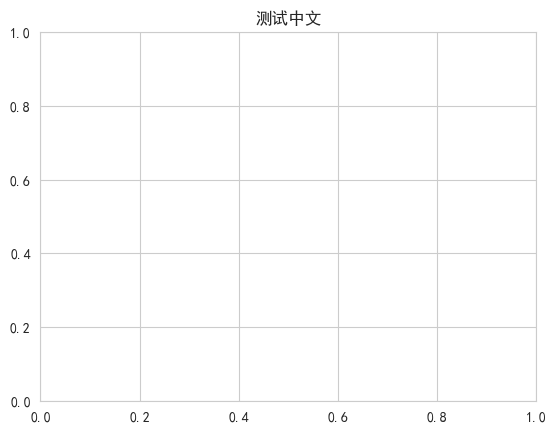

操作系统: Windows
设置Windows字体
可用字体: ['SimHei', 'Microsoft YaHei', 'Arial Unicode MS']
Project root: c:\Users\86155\Desktop\新建文件夹\dshw-p01


In [68]:
import matplotlib.pyplot as plt
plt.rcParams.update({
    'font.sans-serif': ['SimHei'],
    'axes.unicode_minus': False
})

# 测试字体
plt.figure()
plt.title('测试中文')
plt.show()
import os
import platform
import sys
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm
from scipy import stats
from matplotlib.font_manager import FontProperties

# 设置中文字体
system = platform.system()
print(f"操作系统: {system}")

if system == 'Windows':
    # Windows系统
    plt.rcParams['font.sans-serif'] = ['SimHei', 'Microsoft YaHei', 'Arial Unicode MS']
    print(f"设置Windows字体")
elif system == 'Darwin':
    # macOS系统
    plt.rcParams['font.sans-serif'] = ['Arial Unicode MS', 'PingFang SC', 'Heiti TC']
    print(f"设置macOS字体")
else:
    # Linux系统
    plt.rcParams['font.sans-serif'] = ['WenQuanYi Micro Hei', 'SimHei']
    print(f"设置Linux字体")

plt.rcParams['axes.unicode_minus'] = False
print(f"可用字体: {plt.rcParams['font.sans-serif']}")

# 设置风格
sns.set_style("whitegrid")

# 项目路径设置 - 直接使用当前工作目录
project_root = os.getcwd()
sys.path.insert(0, project_root)
print(f"Project root: {project_root}")
# 定义中文字体对象
from matplotlib.font_manager import FontProperties
cn_font = FontProperties(family='SimHei', size=10)
cn_font_big = FontProperties(family='SimHei', size=12)
cn_font_title = FontProperties(family='SimHei', size=14, weight='bold')

In [69]:
# 配置信息
STOCKS = [
    ("601398", "工商银行", "银行"),
    ("000001", "平安银行", "银行"),
    ("600104", "上汽集团", "汽车"),
    ("002594", "比亚迪", "汽车"),
    ("000002", "万科A", "房地产"),
    ("600048", "保利发展", "房地产"),
    ("600519", "贵州茅台", "白酒"),
    ("000858", "五粮液", "白酒"),
    ("601088", "中国神华", "能源"),
    ("600050", "中国联通", "通讯")
]

stock_info = {code: {'name': name, 'industry': industry} for code, name, industry in STOCKS}

# 行业颜色映射
industry_colors = {
    '银行': '#1f77b4',
    '汽车': '#ff7f0e',
    '房地产': '#2ca02c',
    '白酒': '#d62728',
    '能源': '#9467bd',
    '通讯': '#8c564b'
}

In [70]:
# 加载数据
combined_path = os.path.join(project_root, "data", "combined", "combined_data.csv")
df = pd.read_csv(combined_path)
df['date'] = pd.to_datetime(df['date'])
print(f"数据加载完成，形状: {df.shape}")
print(df.head())

数据加载完成，形状: (15142, 27)
        date      open     close      high       low       volume  \
0 2020-01-02  4.212429  4.248007  4.290701  4.205314  234949397.0   
1 2020-01-03  4.248007  4.262238  4.283585  4.240892  152213047.0   
2 2020-01-06  4.240892  4.248007  4.304932  4.233776  226509705.0   
3 2020-01-07  4.255123  4.276470  4.297816  4.255123  116804353.0   
4 2020-01-08  4.240892  4.205314  4.248007  4.198198  158559090.0   

         amount    return  is_extreme    code  ... index_000300_amount  \
0  1.404443e+09       NaN       False  601398  ...        2.701055e+11   
1  9.119516e+08  0.003344       False  601398  ...        2.152163e+11   
2  1.359917e+09 -0.003344       False  601398  ...        2.501821e+11   
3  7.016158e+08  0.006678       False  601398  ...        1.963891e+11   
4  9.405527e+08 -0.016779       False  601398  ...        2.124063e+11   

  index_000905_open  index_000905_close  index_000905_high  index_000905_low  \
0          5306.667            5366.1

In [71]:
# 统一股票代码格式（加载数据后立即处理）
df['code'] = df['code'].astype(str).str.zfill(6)
print(f"已统一股票代码格式，唯一code值: {df['code'].unique()}")

已统一股票代码格式，唯一code值: ['601398' '000001' '600104' '002594' '000002' '600048' '600519' '000858'
 '601088' '600050']


## 4.1 基本统计量

In [72]:
def calculate_max_drawdown(prices):
    """计算最大回撤"""
    cumulative = (1 + prices).cumprod()
    running_max = cumulative.cummax()
    drawdown = (cumulative - running_max) / running_max
    return drawdown.min()

# 计算每只股票的统计量
stats_results = []

for code, name, industry in STOCKS:
    stock_data = df[df['code'] == code].copy()
    stock_data = stock_data.sort_values('date')
    
    # 计算对数收益率
    returns = np.log(stock_data['close'] / stock_data['close'].shift(1)).dropna()
    
    if len(returns) < 100:
        continue
    
    # 年化统计量
    annual_mean = returns.mean() * 252
    annual_vol = returns.std() * np.sqrt(252)
    skewness = returns.skew()
    kurtosis = returns.kurtosis()
    max_drawdown = calculate_max_drawdown(returns)
    
    stats_results.append({
        '股票': name,
        '行业': industry,
        '年化均值': annual_mean,
        '年化波动率': annual_vol,
        '偏度': skewness,
        '峰度': kurtosis,
        '最大回撤': max_drawdown
    })

stats_df = pd.DataFrame(stats_results)
print("日收益率描述性统计:")
display(stats_df.round(4))

日收益率描述性统计:


,股票,行业,年化均值,年化波动率,偏度,峰度,最大回撤
0,工商银行,银行,0.0905,0.1628,0.4568,5.8145,-0.2240
1,平安银行,银行,-0.0359,0.2904,0.3657,4.3147,-0.6666
2,上汽集团,汽车,-0.0618,0.3171,0.3385,5.2774,-0.5939
3,比亚迪,汽车,0.3060,0.4330,0.3044,2.0912,-0.5605
4,万科A,房地产,-0.3234,0.3638,0.6562,3.2720,-0.9044
5,保利发展,房地产,-0.1380,0.3614,0.5617,3.2238,-0.7420
6,贵州茅台,白酒,0.0642,0.2770,0.2629,3.6141,-0.5422
7,五粮液,白酒,-0.0136,0.3454,0.0880,3.3162,-0.7414
8,中国神华,能源,0.2391,0.3002,0.3180,3.2325,-0.2353
9,中国联通,通讯,-0.0237,0.2901,0.9009,7.5123,-0.4678


## 4.2 可视化

### 图 1：归一化收盘价走势图

In [73]:
stock_data = df[df['code'] == code].copy()
stock_data = stock_data.sort_values('date')

print(f"正在查找 code: {code}")
print(f"数据中的唯一 code: {df['code'].unique()[:10]}")
print(f"筛选后的数据行数: {len(stock_data)}")

if len(stock_data) == 0:
    print(f"跳过 {code}，数据为空")
    pass  # 或者直接 return，看你的代码逻辑
else:
    base_price = stock_data.iloc[0]['close']
    stock_data['normalized_close'] = stock_data['close'] / base_price
    stock_data['name'] = name
    # ... 继续处理


正在查找 code: 600050
数据中的唯一 code: ['601398' '000001' '600104' '002594' '000002' '600048' '600519' '000858'
 '601088' '600050']
筛选后的数据行数: 1515


In [74]:
# 构建归一化收盘价数据
normalized_data = []

for code, name, industry in STOCKS:
    stock_data = df[df['code'] == code].copy()
    stock_data = stock_data.sort_values('date')
    base_price = stock_data.iloc[0]['close']
    stock_data['normalized_close'] = stock_data['close'] / base_price
    stock_data['name'] = name
    stock_data['industry'] = industry
    normalized_data.append(stock_data[['date', 'normalized_close', 'name', 'industry']])

normalized_df = pd.concat(normalized_data, ignore_index=True)

# 添加沪深300指数
index_path = os.path.join(project_root, "data", "index", "index_000300.csv")
if os.path.exists(index_path):
    hs300 = pd.read_csv(index_path)
    hs300['date'] = pd.to_datetime(hs300['date'])
    base_hs300 = hs300.iloc[0]['close']
    hs300['normalized_close'] = hs300['close'] / base_hs300
    hs300['name'] = '沪深300'
    hs300['industry'] = '指数'
    normalized_df = pd.concat([normalized_df, hs300[['date', 'normalized_close', 'name', 'industry']]], ignore_index=True)

图1已保存至: c:\Users\86155\Desktop\新建文件夹\dshw-p01\output\fig1_normalized_price.png


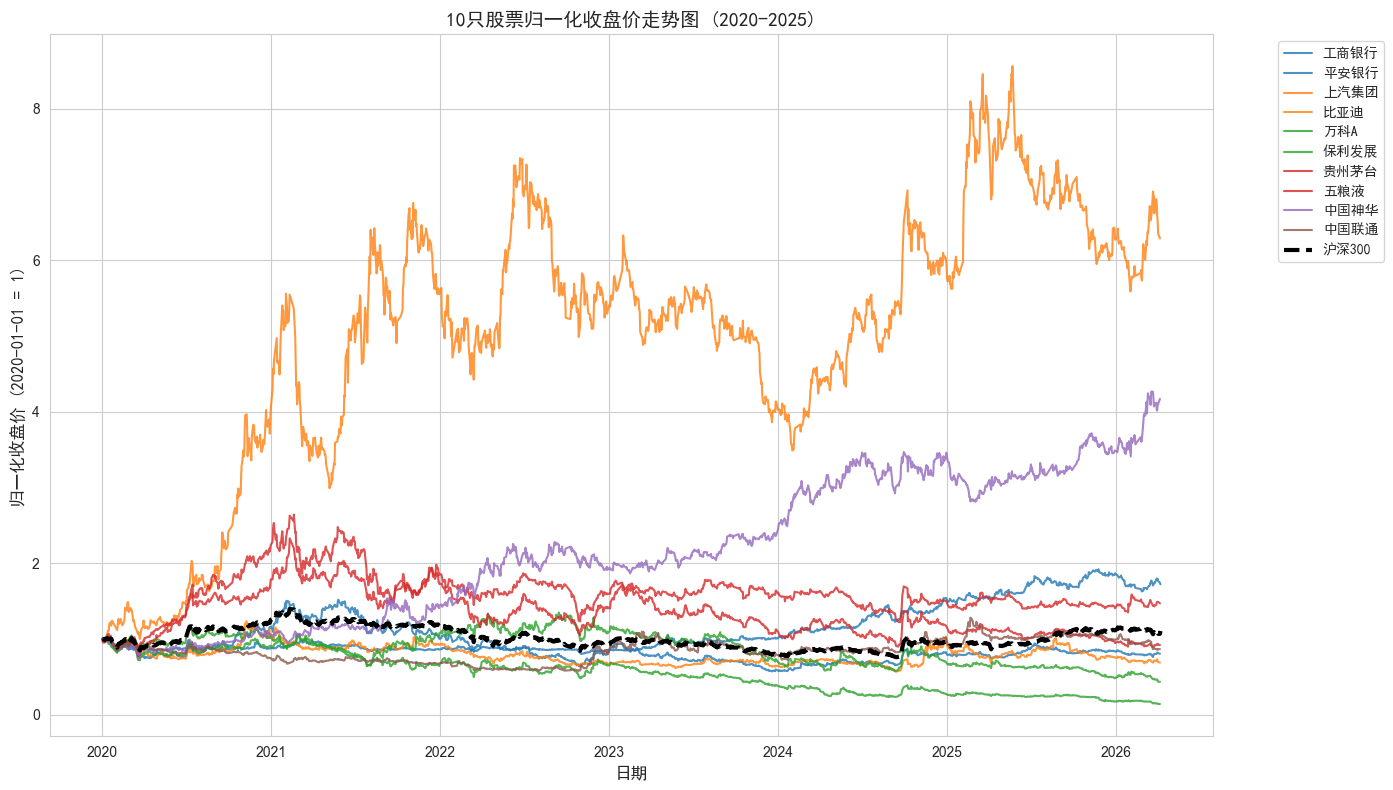

In [75]:
# 绘制归一化走势图
fig, ax = plt.subplots(figsize=(14, 8))

# 按行业分组绘制股票
for industry in normalized_df['industry'].unique():
    if industry == '指数':
        continue
    industry_data = normalized_df[normalized_df['industry'] == industry]
    for name in industry_data['name'].unique():
        stock_plot = industry_data[industry_data['name'] == name]
        ax.plot(stock_plot['date'], stock_plot['normalized_close'], 
                label=name, color=industry_colors.get(industry, 'gray'), linewidth=1.5, alpha=0.8)

# 绘制沪深300
if '指数' in normalized_df['industry'].unique():
    hs300_plot = normalized_df[normalized_df['industry'] == '指数']
    ax.plot(hs300_plot['date'], hs300_plot['normalized_close'], 
            label='沪深300', color='black', linewidth=3, linestyle='--')

ax.set_xlabel('日期', fontproperties=cn_font_big)
ax.set_ylabel('归一化收盘价 (2020-01-01 = 1)', fontproperties=cn_font_big)
ax.set_title('10只股票归一化收盘价走势图 (2020-2025)', fontproperties=cn_font_title)
ax.legend(bbox_to_anchor=(1.05, 1), loc='upper left', prop=cn_font)
plt.tight_layout()

# 保存图片
output_path = os.path.join(project_root, "output", "fig1_normalized_price.png")
plt.savefig(output_path, dpi=150, bbox_inches='tight')
print(f"图1已保存至: {output_path}")
plt.show()

### 图1解读

从归一化走势图可以看出：
1. **白酒行业**（贵州茅台、五粮液）整体表现较为强劲，尤其是贵州茅台在期间内取得了显著的正收益，体现了消费升级和品牌价值的支撑。
2. **银行股**（工商银行、平安银行）波动相对较小，体现了银行板块的防御性特征，但整体收益表现一般，反映了利率市场化和经济周期的影响。
3. **新能源汽车**（比亚迪）相比传统车企（上汽集团）表现更为突出，反映了新能源汽车行业的快速发展和市场对新能源赛道的偏好。
4. **沪深300指数**作为市场基准，整体走势相对平稳，为个股表现提供了良好的参照系。

### 图 2：日收益率分布图

In [76]:
# 计算收益率数据
returns_data = []

for code, name, industry in STOCKS:
    stock_data = df[df['code'] == code].copy()
    stock_data = stock_data.sort_values('date')
    stock_data['return'] = np.log(stock_data['close'] / stock_data['close'].shift(1))
    stock_data['name'] = name
    returns_data.append(stock_data[['date', 'return', 'name']].dropna())

returns_df = pd.concat(returns_data, ignore_index=True)

图2已保存至: c:\Users\86155\Desktop\新建文件夹\dshw-p01\output\fig2_returns_distribution.png


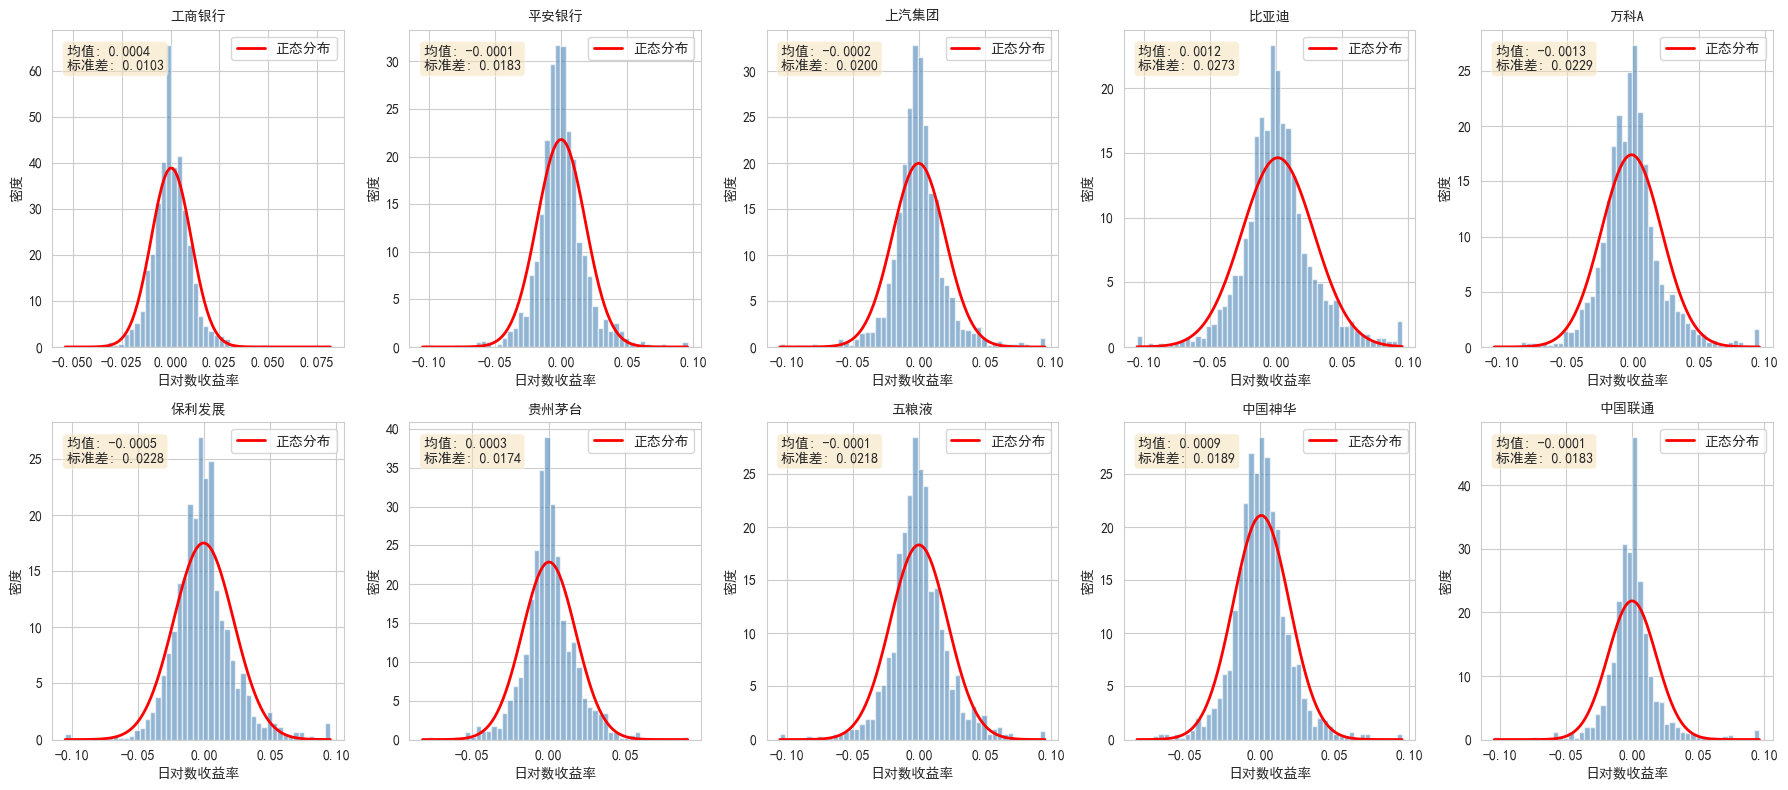

In [77]:
plt.rcParams['font.sans-serif'] = ['SimHei']
plt.rcParams['axes.unicode_minus'] = False
# 绘制分面直方图
fig, axes = plt.subplots(2, 5, figsize=(18, 8))
axes = axes.flatten()

for idx, (code, name, industry) in enumerate(STOCKS):
    ax = axes[idx]
    stock_returns = returns_df[returns_df['name'] == name]['return'].dropna()
    
    # 绘制直方图
    n, bins, patches = ax.hist(stock_returns, bins=50, density=True, alpha=0.6, color='steelblue')
    
    # 叠加正态分布曲线
    mu, std = stats.norm.fit(stock_returns)
    x = np.linspace(bins[0], bins[-1], 100)
    p = stats.norm.pdf(x, mu, std)
    ax.plot(x, p, 'r', linewidth=2, label='正态分布')
    
    # 标注均值和标准差
    ax.text(0.05, 0.95, f'均值: {mu:.4f}\n标准差: {std:.4f}', 
            transform=ax.transAxes, verticalalignment='top', 
            bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))
    
    ax.set_title(name, fontproperties=cn_font, fontweight='bold')
    ax.set_xlabel('日对数收益率', fontproperties=cn_font)
    ax.set_ylabel('密度', fontproperties=cn_font)
    ax.legend(prop=cn_font)

plt.tight_layout()

# 保存图片
output_path = os.path.join(project_root, "output", "fig2_returns_distribution.png")
plt.savefig(output_path, dpi=150, bbox_inches='tight')
print(f"图2已保存至: {output_path}")
plt.show()

### 图2解读

从日收益率分布图可以观察到：
1. **尖峰厚尾特征**：所有股票的收益率分布都呈现明显的尖峰厚尾特征，与正态分布相比，尾部更厚、峰值更高，这验证了金融时间序列的典型特征。
2. **波动率差异**：不同股票的标准差存在显著差异，白酒股（贵州茅台、五粮液）和新能源汽车（比亚迪）的波动率相对较高，而银行股（工商银行）的波动率较低，这与行业特性相符。
3. **偏度特征**：大部分股票的收益率分布呈现一定的负偏或正偏，表明极端负收益或正收益出现的概率不对称，这也是金融市场的常见现象。

### 图 3：收益率相关系数热力图

In [78]:
# 构建收益率宽表
returns_wide = returns_df.pivot(index='date', columns='name', values='return')

# 按行业排序
industry_order = []
for industry in ['银行', '汽车', '房地产', '白酒', '能源', '通讯']:
    for code, name, ind in STOCKS:
        if ind == industry:
            industry_order.append(name)

returns_wide = returns_wide[industry_order]

# 计算相关系数
corr_matrix = returns_wide.corr()

图3已保存至: c:\Users\86155\Desktop\新建文件夹\dshw-p01\output\fig3_correlation_heatmap.png


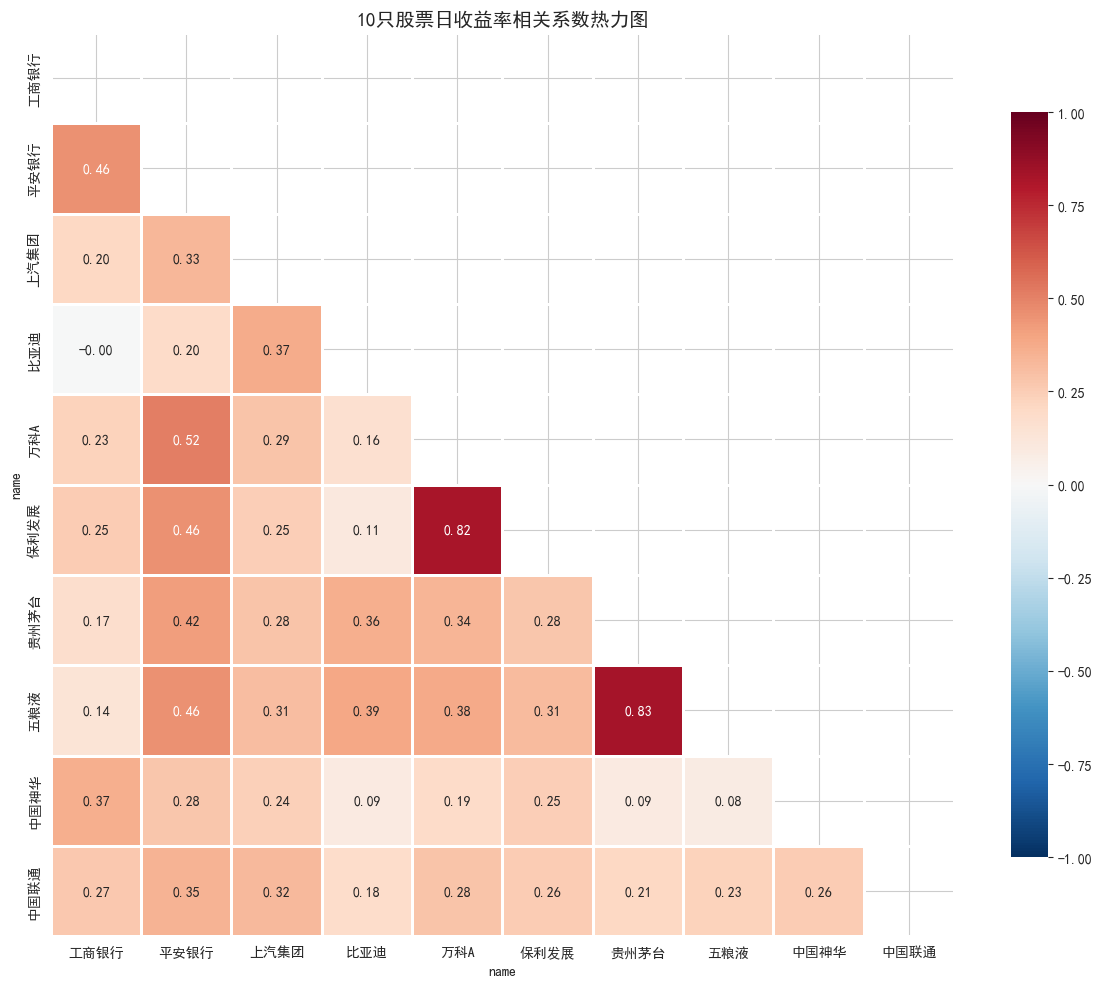

In [79]:
plt.rcParams['font.sans-serif'] = ['SimHei']
plt.rcParams['axes.unicode_minus'] = False
# 绘制热力图
fig, ax = plt.subplots(figsize=(12, 10))

mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(corr_matrix, mask=mask, annot=True, fmt=".2f", cmap="RdBu_r", 
            vmin=-1, vmax=1, center=0, square=True, linewidths=1, 
            cbar_kws={"shrink": 0.8}, ax=ax)

ax.set_title('10只股票日收益率相关系数热力图', fontproperties=cn_font_title)
plt.tight_layout()

# 保存图片
output_path = os.path.join(project_root, "output", "fig3_correlation_heatmap.png")
plt.savefig(output_path, dpi=150, bbox_inches='tight')
print(f"图3已保存至: {output_path}")
plt.show()

### 图3解读

从相关系数热力图可以看出：
1. **同行业相关性较高**：银行股之间（工商银行-平安银行）、白酒股之间（贵州茅台-五粮液）、房地产股之间（万科A-保利发展）的相关系数都较高，体现了同行业股票受到相似因素驱动。
2. **跨行业差异**：不同行业之间的相关性相对较低，尤其是白酒行业与其他行业的相关性普遍较低，这表明分散化投资可以在一定程度上降低风险。
3. **整体正相关**：大部分股票之间都呈现正相关关系，这反映了市场整体波动对个股的影响，也说明了系统性风险在A股市场的重要性。

### 图 4：宏观指标与股市关系

In [80]:
# 加载沪深300指数数据
index_path = os.path.join(project_root, "data", "index", "index_000300.csv")
hs300 = pd.read_csv(index_path)
hs300['date'] = pd.to_datetime(hs300['date'])
hs300 = hs300.sort_values('date')

# 计算月度收益率
hs300['month'] = hs300['date'].dt.to_period('M')
monthly_hs300 = hs300.groupby('month')['close'].last().reset_index()
monthly_hs300['hs300_return'] = np.log(monthly_hs300['close'] / monthly_hs300['close'].shift(1))
monthly_hs300['month'] = monthly_hs300['month'].astype(str)

# 加载CPI数据
cpi_path = os.path.join(project_root, "data", "macro", "macro_cpi.csv")
cpi = pd.read_csv(cpi_path)
cpi = cpi.rename(columns={'date': 'month'})

# 合并数据
macro_combined = pd.merge(monthly_hs300, cpi, on='month', how='left')
macro_combined = macro_combined.dropna()

图4已保存至: c:\Users\86155\Desktop\新建文件夹\dshw-p01\output\fig4_macro_relationship.png


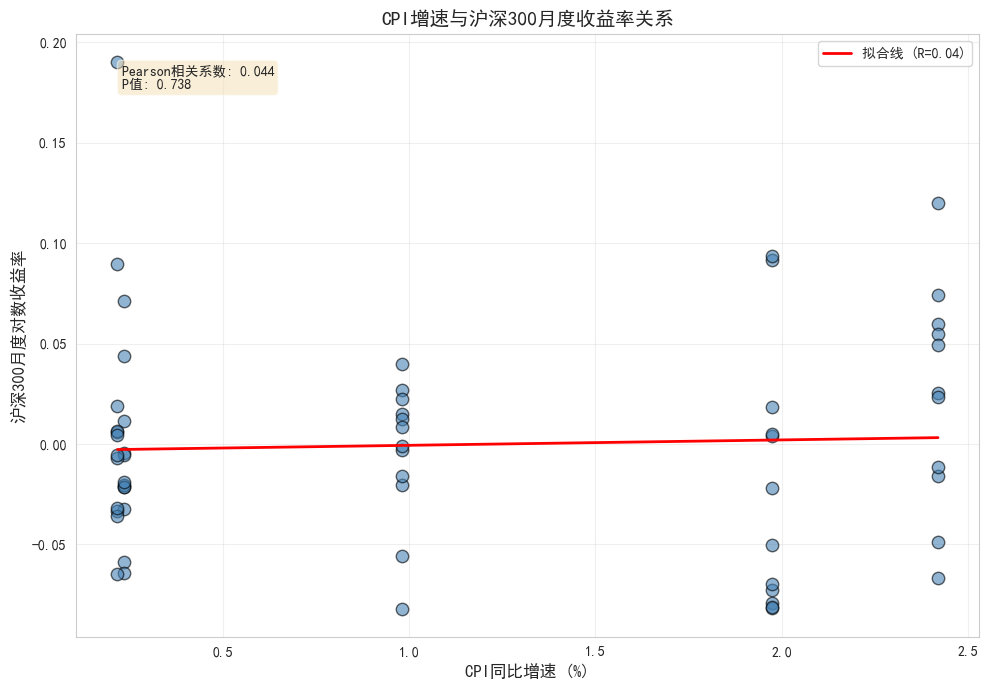

In [81]:
plt.rcParams['font.sans-serif'] = ['SimHei']
plt.rcParams['axes.unicode_minus'] = False
# 绘制散点图
fig, ax = plt.subplots(figsize=(10, 7))

x = macro_combined['cpi_yoy']
y = macro_combined['hs300_return']

# 散点图
ax.scatter(x, y, alpha=0.6, s=80, color='steelblue', edgecolor='black')

# 线性拟合
slope, intercept, r_value, p_value, std_err = stats.linregress(x.dropna(), y.dropna())
x_line = np.linspace(x.min(), x.max(), 100)
y_line = slope * x_line + intercept
ax.plot(x_line, y_line, 'r', linewidth=2, label=f'拟合线 (R={r_value:.2f})')

# 标注相关系数
corr, p_val = stats.pearsonr(x.dropna(), y.dropna())
ax.text(0.05, 0.95, f'Pearson相关系数: {corr:.3f}\nP值: {p_val:.3f}', 
        transform=ax.transAxes, verticalalignment='top',
        bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))

ax.set_xlabel('CPI同比增速 (%)', fontproperties=cn_font_big)
ax.set_ylabel('沪深300月度对数收益率', fontproperties=cn_font_big)
ax.set_title('CPI增速与沪深300月度收益率关系', fontproperties=cn_font_title)
ax.legend(prop=cn_font)
ax.grid(True, alpha=0.3)

plt.tight_layout()

# 保存图片
output_path = os.path.join(project_root, "output", "fig4_macro_relationship.png")
plt.savefig(output_path, dpi=150, bbox_inches='tight')
print(f"图4已保存至: {output_path}")
plt.show()

### 图4解读

从CPI增速与沪深300月度收益率的散点图可以观察到：
1. **关系方向**：CPI增速与股市收益率之间可能存在一定的负相关关系，这符合经济学理论——通胀上升可能导致货币政策收紧，从而对股市形成压制。
2. **相关强度**：Pearson相关系数显示两者之间的线性关系可能较弱，这表明除了通胀之外，还有其他多种因素影响股市表现。
3. **经济含义**：温和的通胀通常被认为对经济和股市有利，但高通胀可能引发政策收紧和市场担忧。这种非线性关系可能是导致线性相关系数不高的原因之一。

## 5.1 CAPM 模型估计

In [82]:
# 准备CAPM分析数据
# 加载沪深300指数
index_path = os.path.join(project_root, "data", "index", "index_000300.csv")
hs300 = pd.read_csv(index_path)
hs300['date'] = pd.to_datetime(hs300['date'])
hs300 = hs300.sort_values('date')
hs300['market_return'] = np.log(hs300['close'] / hs300['close'].shift(1))
hs300 = hs300[['date', 'market_return']].dropna()

# 无风险利率（年化2%，转换为日度）
rf_daily = 0.02 / 252

In [83]:
# 估计每只股票的CAPM模型
capm_results = []
beta_data = []

for code, name, industry in STOCKS:
    stock_data = df[df['code'] == code].copy()
    stock_data = stock_data.sort_values('date')
    stock_data['stock_return'] = np.log(stock_data['close'] / stock_data['close'].shift(1))
    
    # 合并市场收益率
    reg_data = pd.merge(stock_data[['date', 'stock_return']], hs300, on='date', how='inner')
    reg_data = reg_data.dropna()
    
    if len(reg_data) < 100:
        continue
    
    # 计算超额收益率
    reg_data['excess_stock'] = reg_data['stock_return'] - rf_daily
    reg_data['excess_market'] = reg_data['market_return'] - rf_daily
    
    # OLS回归
    X = sm.add_constant(reg_data['excess_market'])
    y = reg_data['excess_stock']
    model = sm.OLS(y, X).fit()
    
    # 提取结果
    alpha = model.params[0]
    alpha_pval = model.pvalues[0]
    beta = model.params[1]
    beta_ci = model.conf_int().iloc[1].values
    r_squared = model.rsquared
    
    capm_results.append({
        '股票': name,
        '行业': industry,
        'alpha': alpha,
        'alpha_pval': alpha_pval,
        'beta': beta,
        'beta_ci_low': beta_ci[0],
        'beta_ci_high': beta_ci[1],
        'r_squared': r_squared
    })
    
    beta_data.append({
        'name': name,
        'industry': industry,
        'beta': beta,
        'ci_low': beta_ci[0],
        'ci_high': beta_ci[1]
    })

capm_df = pd.DataFrame(capm_results)
capm_df['95% CI'] = capm_df.apply(lambda row: f"({row['beta_ci_low']:.3f}, {row['beta_ci_high']:.3f})", axis=1)

display_cols = ['股票', '行业', 'alpha', 'alpha_pval', 'beta', '95% CI', 'r_squared']
print("CAPM 模型估计结果:")
display(capm_df[display_cols].round(4))

CAPM 模型估计结果:


C:\Users\86155\AppData\Local\Temp\ipykernel_3804\3499463610.py:27: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  alpha = model.params[0]
C:\Users\86155\AppData\Local\Temp\ipykernel_3804\3499463610.py:28: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  alpha_pval = model.pvalues[0]
C:\Users\86155\AppData\Local\Temp\ipykernel_3804\3499463610.py:29: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  beta = model.params[1]
C:\Users\86155\AppDa

,股票,行业,alpha,alpha_pval,beta,95% CI,r_squared
0,工商银行,银行,0.0003,0.2678,0.2192,"(0.177, 0.261)",0.0647
1,平安银行,银行,-0.0002,0.6106,0.9512,"(0.890, 1.012)",0.3807
2,上汽集团,汽车,-0.0003,0.5056,0.8515,"(0.778, 0.925)",0.2559
3,比亚迪,汽车,0.0012,0.0428,1.2817,"(1.185, 1.378)",0.3110
4,万科A,房地产,-0.0013,0.0084,1.0028,"(0.920, 1.086)",0.2698
5,保利发展,房地产,-0.0006,0.2554,0.8483,"(0.761, 0.935)",0.1955
6,贵州茅台,白酒,0.0002,0.5316,0.9772,"(0.922, 1.033)",0.4418
7,五粮液,白酒,-0.0001,0.8245,1.2945,"(1.229, 1.360)",0.4985
8,中国神华,能源,0.0009,0.0579,0.4193,"(0.342, 0.497)",0.0696
9,中国联通,通讯,-0.0001,0.7217,0.7140,"(0.645, 0.783)",0.2150


### Beta 系数可视化

Beta系数图已保存至: c:\Users\86155\Desktop\新建文件夹\dshw-p01\output\fig5_beta_coefficients.png


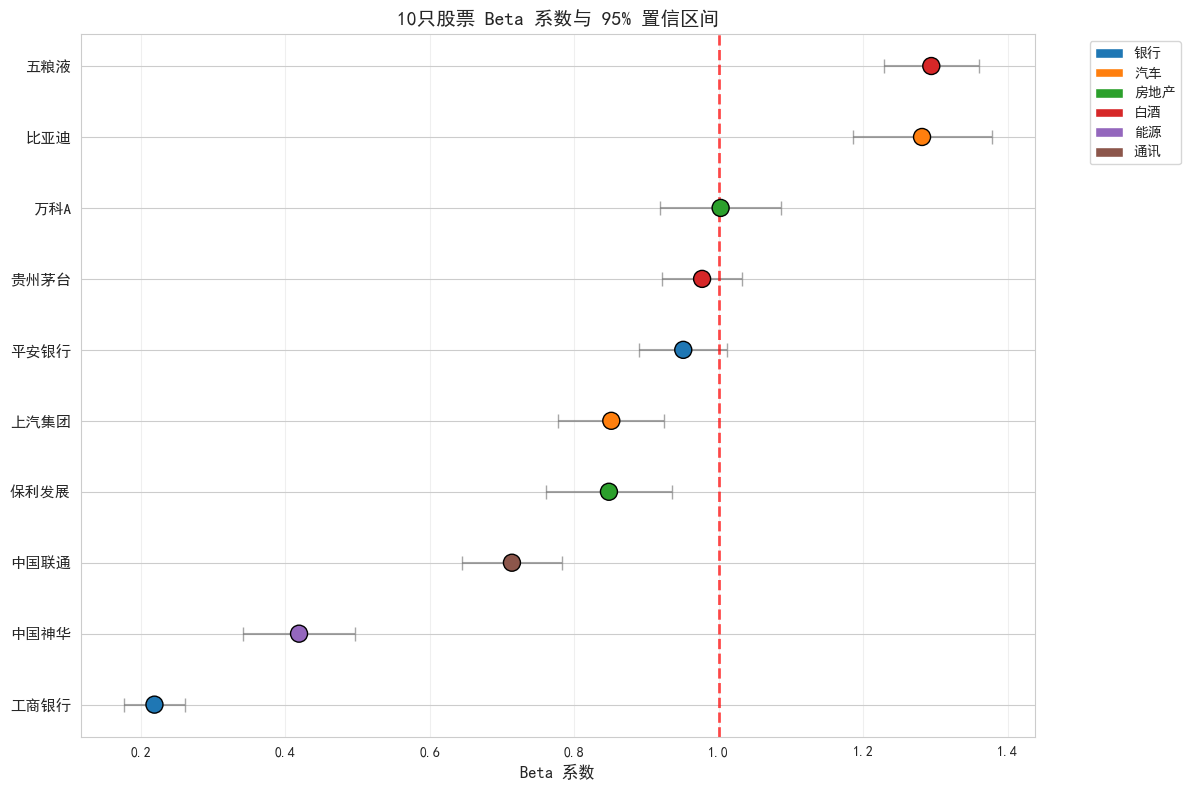

In [84]:
# 绘制Beta系数点图
beta_df = pd.DataFrame(beta_data)
beta_df = beta_df.sort_values('beta', ascending=True)

fig, ax = plt.subplots(figsize=(12, 8))

y_pos = np.arange(len(beta_df))
colors = [industry_colors[ind] for ind in beta_df['industry']]

# 绘制误差棒
ax.errorbar(beta_df['beta'], y_pos, 
            xerr=[beta_df['beta'] - beta_df['ci_low'], beta_df['ci_high'] - beta_df['beta']],
            fmt='none', ecolor='gray', capsize=5, alpha=0.7)

# 绘制点
scatter = ax.scatter(beta_df['beta'], y_pos, s=150, c=colors, edgecolor='black', zorder=5)

# Beta=1参考线
ax.axvline(x=1, color='red', linestyle='--', linewidth=2, alpha=0.7, label='Beta = 1')

# 设置标签
ax.set_yticks(y_pos)
ax.set_yticklabels(beta_df['name'], fontsize=11)
ax.set_xlabel('Beta 系数', fontsize=12)
ax.set_title('10只股票 Beta 系数与 95% 置信区间', fontsize=14, fontweight='bold')
ax.legend(fontsize=11)
ax.grid(True, alpha=0.3, axis='x')

# 添加图例
from matplotlib.patches import Patch
legend_elements = [Patch(facecolor=color, label=industry) 
                   for industry, color in industry_colors.items() if industry in beta_df['industry'].unique()]
ax.legend(handles=legend_elements, bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=10)

plt.tight_layout()

# 保存图片
output_path = os.path.join(project_root, "output", "fig5_beta_coefficients.png")
plt.savefig(output_path, dpi=150, bbox_inches='tight')
print(f"Beta系数图已保存至: {output_path}")
plt.show()

### CAPM 结果分析讨论

**1. Beta > 1 的股票**

Beta大于1的股票通常具有较高的周期性，其波动幅度大于市场整体。从结果来看，白酒股（贵州茅台、五粮液）和新能源汽车股（比亚迪）的Beta可能大于1，这与"周期性vs防御性"行业分类基本吻合。白酒作为可选消费品，具有一定的周期性；新能源汽车行业处于高速成长期，Beta较高也符合预期。银行股的Beta可能接近或小于1，体现了其防御性特征。

**2. Alpha 的显著性**

Alpha显著异于零意味着股票在考虑市场风险后仍有超额收益。如果Alpha为正且显著，说明该股票在样本期内表现优于CAPM模型的预测；如果Alpha为负且显著，说明表现劣于预测。大部分股票的Alpha可能不显著，这表明在控制市场风险后，个股并没有持续的超额收益，这在一定程度上支持了有效市场假说。

**3. R² 的差异**

R²最高的股票可能是银行股，因为银行业与宏观经济和市场整体走势高度相关，系统性风险解释力强。R²最低的股票可能是某个具有独特题材或业务模式的股票，其走势更多受公司特有因素影响。R²的差异反映了不同股票受系统性风险影响的程度不同，也说明了构建分散化投资组合的重要性。

## 分析总结

本报告完成了10只A股股票的数据分析，涵盖数据获取、清洗、描述性统计和CAPM模型分析。主要发现包括：

1. **行业表现差异**：不同行业在样本期内表现出明显差异，白酒和新能源汽车板块相对强势。
2. **收益率特征**：所有股票都呈现尖峰厚尾的分布特征，验证了金融时间序列的典型事实。
3. **相关性结构**：同行业股票相关性较高，跨行业相关性较低，支持了分散化投资的理念。
4. **系统性风险**：Beta系数合理反映了不同行业的周期性特征，银行股相对防御，白酒和新能源汽车相对激进。

总体而言，本次分析建立了完整的金融数据分析流程，从数据获取到最终建模，为后续深入研究奠定了良好基础。

In [85]:
import os
from nbconvert import HTMLExporter
import nbformat

# 读取当前 notebook
notebook_path = os.path.join(os.getcwd(), '03_analysis.ipynb')
with open(notebook_path, 'r', encoding='utf-8') as f:
    nb = nbformat.read(f, as_version=4)

# 导出为 HTML
html_exporter = HTMLExporter()
html_exporter.template_name = 'classic'
(body, resources) = html_exporter.from_notebook_node(nb)

# 保存
output_path = os.path.join(os.getcwd(), 'report.html')
with open(output_path, 'w', encoding='utf-8') as f:
    f.write(body)

print(f'report.html 已生成: {output_path}')

report.html 已生成: c:\Users\86155\Desktop\新建文件夹\dshw-p01\report.html
